Date: 25th July 2026

Author: Bipul Pandey

Objectives: 
    - We will load various models.
    - We will load the training data and the generated data
    - We will compute Energy at each layer as well as the total energy
    - we will visualize these energies for both data sets


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import r2_score
from scipy.stats import pearsonr

import sys
sys.path.append("../Scripts/")
from LRBM_Compressed_Potts import *


print("="*30 ,"Options:", "="*30)
print("     1 : Toy model of evolution")
print("     2: Images- MNIST")
print("     3: Sentences - Animal Simple Wikipedia")
print("     4: Sentences - Alice in Wonderland")
print("     5: Protein - Chorismate Mutase")
print("="*70)


============================== Options: ==============================
     1 : Toy model of evolution
     2: Images- MNIST
     3: Sentences - Animal Simple Wikipedia
     4: Sentences - Alice in Wonderland
     5: Protein - Chorismate Mutase


In [3]:
def Energy_Given_Model(Ohe_Array, Model):
    num_part = Model.num_of_partitions
    Energy_by_scale ={}
    Total_Energy = np.zeros(len(Ohe_Array))
    for p in range(0, num_part):
        Data_self, Data_interact = Model.Data_Partition(Ohe_Array, p)
        Weight_part = Model.Weights[p]
        Bias_part = Model.Bias[p]
        Energy_p = Model.Energy_Array_given_partition_easy(Ohe_Array, p)
        name_p = f"Scale_{p+1}_Energy"
        Energy_by_scale[name_p] = Energy_p
        Total_Energy+=Energy_p
    Energy_by_scale["Total_Energy"] = Total_Energy

    return Energy_by_scale

In [4]:
Experiment = 1


Experiment = int(Experiment)

if Experiment ==1:
    print("Population Toy Model")
    Data_loc = "../../Training_Data/Toy_Model_Evolution/Training_Data_Final_5000_Ground_Truth_Population.csv"
    Gen_loc = "../../Results/Generated_Data/Toy_Model_Evolution/LRBM_Generated_Population.csv"
    Model_loc = "../../Model_Parameters/Toy_Model_Evolution_LRBM_Toy/"
    Compress_Alphabets = False

elif Experiment ==2:
    print("MNIST")
    Data_loc =  "../../Training_Data/Images_MNIST/Training_Data_MNIST_Binarized_500_images.csv"
    Gen_loc = "../../Results/Generated_Data/Images_MNIST/LRBM_Generated_MNIST_Images.csv"
    Model_loc ="../../Model_Parameters/Images_LRBM_MNIST/"
    Compress_Alphabets = False

elif Experiment == 3:
    print("Sentences- Animal:Simple Wikipedia")
    Data_loc = "../../Training_Data/Sentences_Wiki/Training_Data_Wiki_1589_Tokenized_Sentences.csv"
    Gen_loc = "../../Results/Generated_Data/Sentences_Wiki/LRBM_Generated_Wiki_Sentences.csv"
    Model_loc =  "../../Model_Parameters/Sentences_LRBM_Wiki/"
    Compress_Alphabets = True

elif Experiment ==4:
    print("Sentences - Alice in Wonderland")
    Data_loc ="../../Training_Data/Sentences_Alice/Training_Data_Alice_716_Tokenized_Sentences.csv"
    Gen_loc = "../../Results/Generated_Data/Sentences_Alice/LRBM_Generated_Alice_Sentences.csv"
    Model_loc =  "../../Model_Parameters/Sentences_LRBM_Alice/"
    Compress_Alphabets = True

else:
    Experiment == 5
    print("Protein : Chorismate Mutase")
    Data_loc = "../../Training_Data/Protien_Chorismate_Mutase/Training_Data_Natural_1130_Chorismate_Mutase.csv"
    Gen_loc = "../../Results/Generated_Data/Protein_Chorismate_Mutase/LRBM_Generated_Chorismate_Mutase.csv"
    Model_loc =  "../../Model_Parameters/Proteins_LRBM_CM/"
    Compress_Alphabets = False


Population Toy Model


In [5]:
## Loading Training Data: ---
Training_Dataset = pd.read_csv(Data_loc)

Columns = Training_Dataset.columns
Postion_Columns=[]
for c in Columns:
    if c[0:3] == "Pos":
        Postion_Columns.append(c)
print("Number of Positions=", len(Postion_Columns))
Compact_Training_Dataset = np.array(Training_Dataset[Postion_Columns])

## Loading Generated Data: ---
Gen_Dataset = pd.read_csv(Gen_loc)
Compact_LRBM_Generated_Dataset = np.array(Gen_Dataset[Postion_Columns])
##------------

## ----Loading Scales ----
Entropic_Partition_Map = np.loadtxt(Model_loc+"Entropic_Scales_Partition_Map.txt")


Number of Positions= 16


In [6]:
LRBM = Compressed_LRBM(Compact_Training_Dataset, Entropic_Partition_Map, compressed=Compress_Alphabets, extra_character="*zz")

Number of Partitions Set= 4
..Setting Partition Map..
Number of partitions = 4
semi-warm start. Matching only the frequencies
semi-warm start. Matching only the frequencies


In [7]:
## We also want to import the trained model weights and biases:

Load_Model_Parameters= True

if Load_Model_Parameters:
    print("Loading Trained Model Parameters.")
    num_scales = np.shape(Entropic_Partition_Map)[0]
    for s in range(0, num_scales):
        Weight_s = np.loadtxt(Model_loc+ f"Scale_{s+1}_Weight.txt")
        Bias_s = np.loadtxt(Model_loc+ f"Scale_{s+1}_Bias.txt")
        LRBM.Weights[s] = Weight_s
        LRBM.Bias[s] = Bias_s
        print(f"Scale_{s+1} Parameters Loaded.")
        
else:
    print("Model Parameters are Random Initial Values")


Loading Trained Model Parameters.
Scale_1 Parameters Loaded.
Scale_2 Parameters Loaded.
Scale_3 Parameters Loaded.
Scale_4 Parameters Loaded.


## Visualizing One hot encoded Training Data:

In [8]:
## One hot encoded Training data
Ohe_training_data = LRBM.unfurled_data

## One hot encoded Generated Data
Ohe_generated_data = []
for elem in Compact_LRBM_Generated_Dataset:
    Ohe_generated_data.append(LRBM.One_hot_encoder(elem))

Ohe_generated_data = np.array(Ohe_generated_data)

Text(0.5, 1.0, 'One hot encoded Generated Dataset')

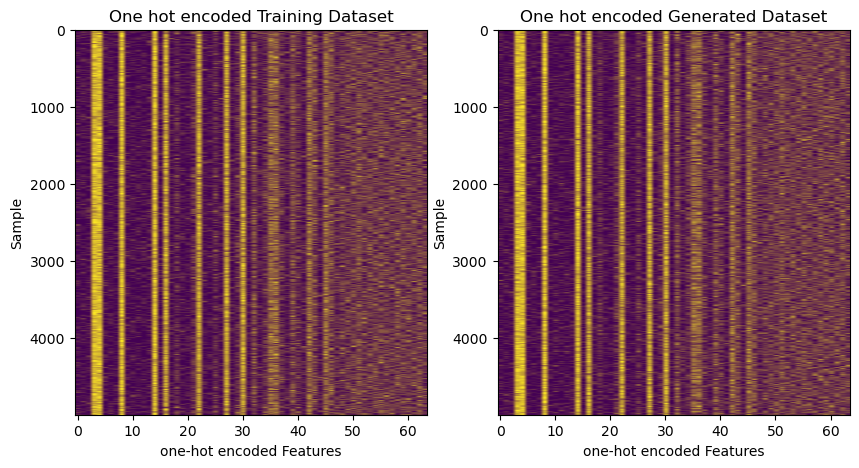

In [9]:
fig, ax = plt.subplots(1,2,figsize=(10,5))
ax[0].imshow(Ohe_training_data, aspect = "auto")
ax[1].imshow(Ohe_generated_data,aspect = "auto")

for i in range(0,2):
    ax[i].set_xlabel("one-hot encoded Features")
    ax[i].set_ylabel("Sample")
ax[0].set_title("One hot encoded Training Dataset")
ax[1].set_title("One hot encoded Generated Dataset")

## Energy Calculations for Training and Generated Dataset:

In [10]:
Energy_evol_Training_Data = Energy_Given_Model(Ohe_training_data, LRBM)
Energy_evol_Generated_Data = Energy_Given_Model(Ohe_generated_data, LRBM)

-----------------
## Energy Evolution Plots:

### 1. Scale wise Energy:
Now we will plot the energy contribution by each scale for both training and generated data

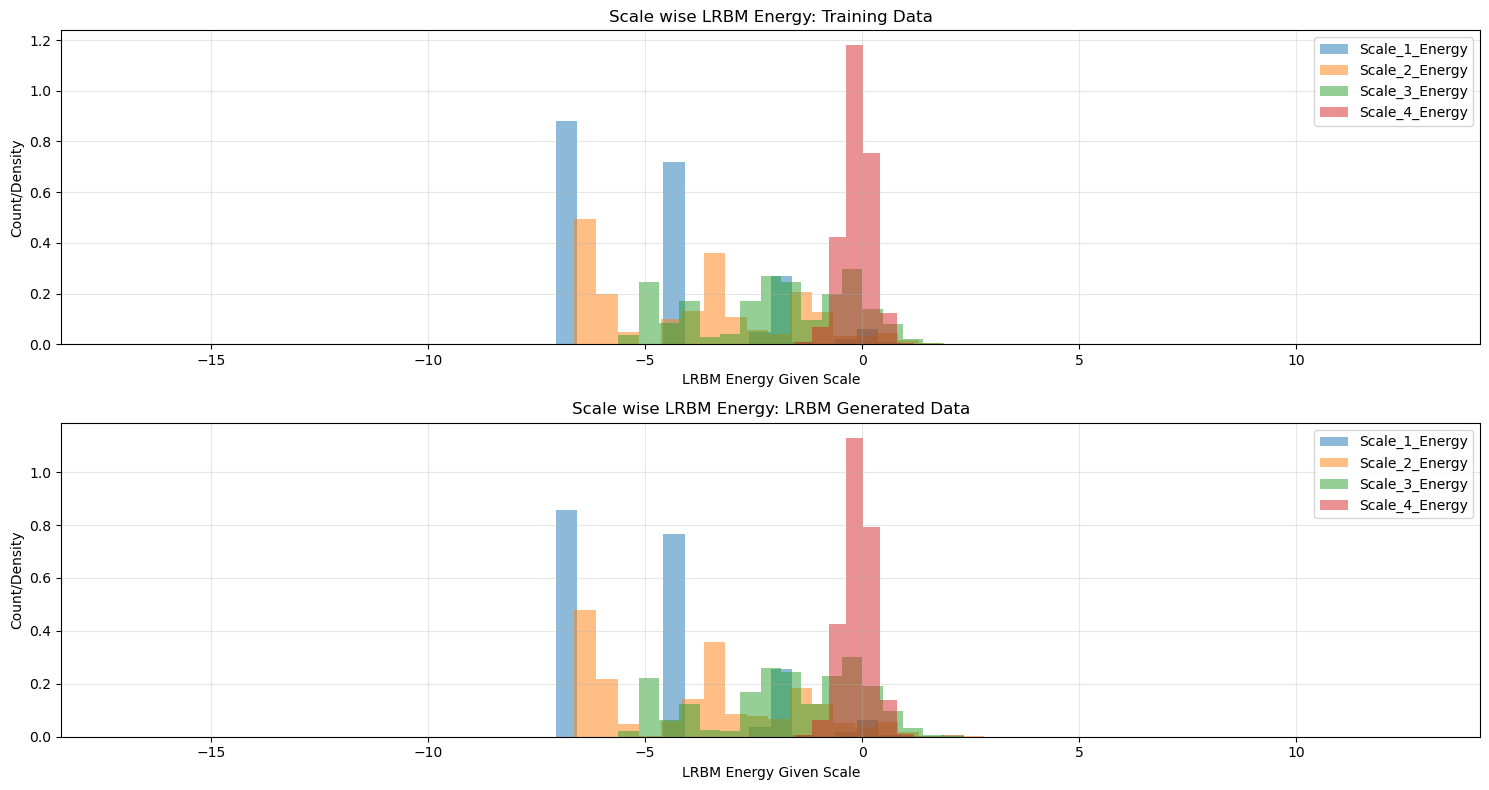

In [11]:
num_bins = 60
density = True

###--------------------
fig,ax = plt.subplots(2,1,figsize=(15,8))

for i in range(0, LRBM.num_of_partitions):
    scale_name = f"Scale_{i+1}_Energy"
    cts_train, bins_train = np.histogram(Energy_evol_Training_Data[scale_name], num_bins)
    cts_gen, bins_gen = np.histogram(Energy_evol_Generated_Data[scale_name], num_bins)
    max_val = np.max([bins_train[-1], bins_gen[-1]])+10
    min_val = np.min([bins_train[0], bins_gen[0]])-10

    Bin_used = np.linspace(min_val, max_val, num_bins)

    ax[0].hist(Energy_evol_Training_Data[scale_name], bins = Bin_used, density=density, alpha = 0.5, label = scale_name)
    ax[1].hist(Energy_evol_Generated_Data[scale_name], bins = Bin_used, density=density, alpha = 0.5,label = scale_name)



for i in range(0,2):
    ax[i].grid(alpha = 0.3)
    ax[i].legend()
    ax[i].set_xlabel("LRBM Energy Given Scale")
    ax[i].set_ylabel("Count/Density")
  

ax[0].set_title("Scale wise LRBM Energy: Training Data")
ax[1].set_title("Scale wise LRBM Energy: LRBM Generated Data")

plt.tight_layout()
plt.show()

### 2. Layer Wise Energy Plot:
This is the cumulative LRBM energy upto any layer


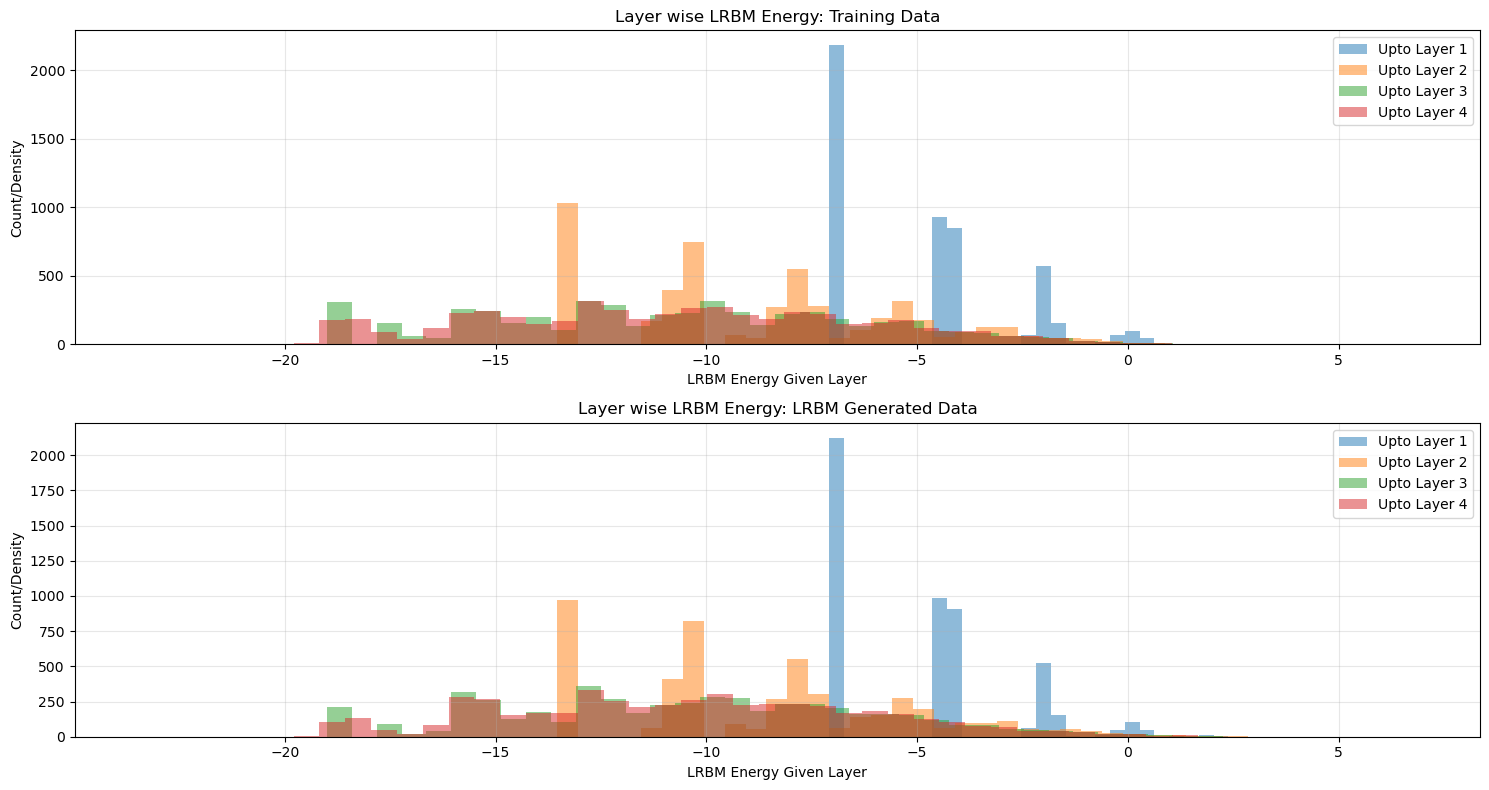

In [12]:
num_bins = 50
density = False

###--------------------
fig,ax = plt.subplots(2,1,figsize=(15,8))

Energy_train = np.zeros(len(Compact_Training_Dataset))
Energy_gen = np.zeros(len(Compact_LRBM_Generated_Dataset))

for i in range(0, LRBM.num_of_partitions):
    scale_name = f"Scale_{i+1}_Energy"
    Layer_name = f"Upto Layer {i+1}"
    Energy_train += Energy_evol_Training_Data[scale_name]
    Energy_gen += Energy_evol_Generated_Data[scale_name]
    ##------
    cts_train, bins_train = np.histogram(Energy_train, num_bins)
    cts_gen, bins_gen = np.histogram(Energy_gen, num_bins)
    max_val = np.max([bins_train[-1], bins_gen[-1]])+4
    min_val = np.min([bins_train[0], bins_gen[0]])-4

    Bin_used = np.linspace(min_val, max_val, num_bins)

    ax[0].hist(Energy_train, bins = Bin_used, density=density, alpha = 0.5, label = Layer_name)
    ax[1].hist(Energy_gen, bins = Bin_used, density=density, alpha = 0.5,label = Layer_name)


for i in range(0,2):
    ax[i].grid(alpha = 0.3)
    ax[i].legend()
    ax[i].set_xlabel("LRBM Energy Given Layer")
    ax[i].set_ylabel("Count/Density")
  

ax[0].set_title("Layer wise LRBM Energy: Training Data")
ax[1].set_title("Layer wise LRBM Energy: LRBM Generated Data")

plt.tight_layout()
plt.show()

End of Notebook.